# Rent Radar — Mumbai Fair-Rent Analysis

**Question:** what should a Mumbai flat actually cost? Listings are noisy — the
same 2BHK is priced wildly differently across localities, floors and furnishing.
This notebook cleans real scraped listings, explores them, and trains **one**
linear regression to predict rent, reporting error in rupees and showing where
the model breaks.

*This notebook is the narrative twin of the reproducible pipeline in
`python/pipeline/` (`01_clean.py` → `02_model.py`). Every cleaning decision is
documented here as it is made — the skill this project proves.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
raw = pd.read_csv(ROOT / "data/raw/mumbai_listings_raw.csv")
print(f"Raw listings: {len(raw)} rows, {raw.shape[1]} columns")
raw.head()

Raw listings: 897 rows, 16 columns


,source,locality,city,bhk,price,price_unit,deposit,area_sqft,floor,total_floors,furnishing,url,scraped_locality,lat,lng,location_exact
0,squareyards,Goregaon West,Mumbai,2.0,75000.0,per_month,NaN,617,33.0,NaN,furnished,https://www.squareyards.com/rental-2-bhk-617-s...,Goregaon West,19.167242,72.841577,True
1,squareyards,Bandra East,Mumbai,3.0,120000.0,per_month,NaN,1000,5.0,NaN,semi-furnished,https://www.squareyards.com/rental-3-bhk-extra...,Bandra East,19.058016,72.844382,True
2,squareyards,Malad East,Mumbai,2.0,80000.0,per_month,NaN,1000,11.0,NaN,furnished,https://www.squareyards.com/rental-2-bhk-1000-...,Malad East,19.188328,72.860617,True
3,squareyards,Kajupada,Mumbai,1.0,350000.0,per_month,NaN,470,NaN,NaN,furnished,https://www.squareyards.com/rental-1-bhk-store...,Kajupada,19.234519,72.870309,True
4,squareyards,Powai,Mumbai,2.0,75000.0,per_month,NaN,671,NaN,NaN,furnished,https://www.squareyards.com/rental-2-bhk-671-s...,Powai,19.111612,72.902057,True


In [2]:
# What's wrong with the raw data? Nulls + impossible values.
pd.DataFrame({
    "null_%": (raw.isnull().mean() * 100).round(0),
}).sort_values("null_%", ascending=False)

,null_%
deposit,100.0
total_floors,61.0
floor,10.0
bhk,6.0
lat,4.0
lng,4.0
source,0.0
locality,0.0
city,0.0
price,0.0


## Cleaning decisions

Each step below states **what** we do and **why**. We work on a copy and print
the row count after each filter so the effect is auditable.

In [3]:
df = raw.copy()
n0 = len(df)

# 1. deposit — 100% null, no signal. Drop rather than invent data.
print("deposit null share:", round(df["deposit"].isnull().mean(), 2))
df = df.drop(columns=["deposit"])

# 2. Impossible rent. Monthly rent above Rs 10,00,000 is a sale price that leaked
#    into the rental feed. Drop (wrong record), don't winsorise (not an extreme rent).
before = len(df)
df = df[(df["price"] >= 5_000) & (df["price"] <= 1_000_000)].copy()
print(f"price filter [5k, 10L]: removed {before - len(df)}, left {len(df)}")

deposit null share: 1.0
price filter [5k, 10L]: removed 6, left 891


In [4]:
# 3. Impossible area. A flat is not 10 sqft or 100,000 sqft — those are typos.
#    They wreck rent_per_sqft and, via the locality median, become leverage points
#    that make a linear-on-log model explode. Keep a physical band [150, 10000].
before = len(df)
print("area range before:", df["area_sqft"].min(), "-", df["area_sqft"].max())
df = df[(df["area_sqft"] >= 150) & (df["area_sqft"] <= 10_000)].copy()
print(f"area filter [150, 10000] sqft: removed {before - len(df)}, left {len(df)}")

area range before: 120 - 100000
area filter [150, 10000] sqft: removed 3, left 888


In [5]:
# 4. Missing BHK -> infer from area (~450 sqft/BHK in Mumbai), clip 1-6. Flagged
#    as an assumption; the alternative was dropping ~12% of rows.
inferred = df["bhk"].isnull() & df["area_sqft"].notnull()
df.loc[inferred, "bhk"] = (df.loc[inferred, "area_sqft"] / 450).round().clip(1, 6)
df = df[df["bhk"].notnull()].copy()
df["bhk"] = df["bhk"].astype(int)
print(f"bhk inferred for {int(inferred.sum())} rows")

# 5. floor: keep where present (a feature), median-fill nulls and FLAG them so the
#    model can learn from missingness. total_floors ~67% null -> dropped (too sparse).
df = df.drop(columns=["total_floors"])
df["floor_missing"] = df["floor"].isnull().astype(int)
df["floor"] = df["floor"].fillna(df["floor"].median())

# 6. Normalise furnishing + locality text.
df["furnishing"] = df["furnishing"].str.strip().str.lower()
df["locality"] = df["locality"].str.strip().str.title()

# 7. Derived unit: rent per sqft (the fair-rent comparison unit).
df["rent_per_sqft"] = (df["price"] / df["area_sqft"]).round(1)

bhk inferred for 49 rows


In [6]:
# 8. Impossible rent_per_sqft. Mumbai realistically sits ~Rs 20-600/sqft.
#    Rs 1/sqft or Rs 900/sqft is a price/area typo -> drop.
before = len(df)
df = df[(df["rent_per_sqft"] >= 20) & (df["rent_per_sqft"] <= 600)].copy()
print(f"rent/sqft filter [20, 600]: removed {before - len(df)}, left {len(df)}")
print(f"\nCLEAN: {len(df)} rows kept out of {n0} raw ({len(df)/n0:.0%}).")

rent/sqft filter [20, 600]: removed 6, left 882

CLEAN: 882 rows kept out of 897 raw (98%).


**Cleaning summary:** we removed sale prices masquerading as rent, impossible
areas and rent-per-sqft typos, inferred missing BHK, and flagged imputed floors.
The reproducible pipeline (`01_clean.py`) applies the identical logic and also
builds the locality-attributes table (metro distance, tier). We load that clean
output next for modelling.

## SQL — the relational questions, answered first

Before any modelling, three questions the pricing team can answer in SQL alone. The two
clean tables load into SQLite and **join** on `locality`; the queries below are the exact
ones in `sql/03_analysis.sql`, run here so their output sits inline with the story.

- **Q1 — JOIN + GROUP BY:** how does rent scale with BHK inside each price tier?
- **Q2 — window function:** rank localities by rent/sqft and measure each one's gap to the city average.
- **Q3 — CTE:** do localities within 1.5 km of a metro command a premium?

In [7]:
# Self-contained: load the two clean tables into an in-memory SQLite and run the
# exact queries from sql/03_analysis.sql (JOIN + GROUP BY, a window function, a CTE).
import sqlite3

con = sqlite3.connect(":memory:")
pd.read_csv(ROOT / "data/clean/listings_clean.csv").to_sql("listings", con, index=False)
pd.read_csv(ROOT / "data/clean/localities.csv").to_sql("localities", con, index=False)

# Q1 — JOIN + GROUP BY: average rent per BHK within each locality tier.
q1 = pd.read_sql_query("""
    SELECT loc.tier, l.bhk,
           COUNT(*)                       AS n,
           ROUND(AVG(l.price))            AS avg_rent,
           ROUND(AVG(l.rent_per_sqft), 1) AS avg_rent_psf
    FROM listings   l
    JOIN localities loc ON l.locality = loc.locality
    WHERE loc.tier IS NOT NULL
    GROUP BY loc.tier, l.bhk
    ORDER BY CASE loc.tier WHEN 'budget' THEN 1 WHEN 'mid' THEN 2 ELSE 3 END, l.bhk
""", con)
print("Q1 - avg rent by tier x BHK (JOIN + GROUP BY):")
display(q1)

# Q2 - WINDOW: rank localities by rent/sqft; gap to the city-wide average.
q2 = pd.read_sql_query("""
    SELECT locality, tier, n_listings, median_rent_per_sqft,
           RANK() OVER (ORDER BY median_rent_per_sqft DESC)                  AS psf_rank,
           ROUND(median_rent_per_sqft - AVG(median_rent_per_sqft) OVER (), 1) AS gap_to_city_avg
    FROM localities
    WHERE n_listings >= 2            -- ignore thin single-listing localities
    ORDER BY psf_rank
    LIMIT 10
""", con)
print("\nQ2 - locality ranking with gap to city average (WINDOW):")
display(q2)

# Q3 - CTE: isolate metro-proximate localities, then compare rent/sqft.
q3 = pd.read_sql_query("""
    WITH metro_band AS (
        SELECT median_rent_per_sqft,
               CASE WHEN avg_metro_km <= 1.5 THEN 'near_metro' ELSE 'far_metro' END AS band
        FROM localities
        WHERE avg_metro_km IS NOT NULL
    )
    SELECT band, COUNT(*)                         AS n_localities,
           ROUND(AVG(median_rent_per_sqft), 1)    AS avg_rent_psf
    FROM metro_band
    GROUP BY band
    ORDER BY avg_rent_psf DESC
""", con)
print("\nQ3 - near-metro vs far-metro premium (CTE):")
display(q3)
con.close()

Q1 - avg rent by tier x BHK (JOIN + GROUP BY):


,tier,bhk,n,avg_rent,avg_rent_psf
0,budget,1,111,44761.0,99.3
1,budget,2,195,69849.0,92.6
2,budget,3,77,112604.0,93.6
3,budget,4,5,279000.0,120.3
4,budget,5,26,103731.0,100.2
5,budget,6,2,525000.0,127.8
6,mid,1,52,63363.0,138.7
7,mid,2,136,83213.0,110.8
8,mid,3,90,161071.0,124.2
9,mid,4,18,323111.0,154.1



Q2 - locality ranking with gap to city average (WINDOW):


,locality,tier,n_listings,median_rent_per_sqft,psf_rank,gap_to_city_avg
0,Worli,premium,20,251.80,1,127.6
1,Mahalaxmi,premium,9,226.30,2,102.1
2,Navin Nagar,premium,2,214.30,3,90.1
3,Khar West,premium,11,200.00,4,75.8
4,Mahim West,premium,4,197.55,5,73.4
5,Juhu,premium,12,190.50,6,66.3
6,Bandra West,premium,23,188.20,7,64.0
7,Prabhadevi,premium,10,183.30,8,59.1
8,Lower Parel,premium,14,181.35,9,57.2
9,Colaba,premium,4,174.25,10,50.1



Q3 - near-metro vs far-metro premium (CTE):


,band,n_localities,avg_rent_psf
0,near_metro,39,137.0
1,far_metro,52,124.9


**What the SQL says:** premium localities rent for roughly **2× per sqft** what budget
ones do (a 2BHK: ₹184.6 vs ₹92.6/sqft), **Worli** tops the city at ₹251.8/sqft (₹127.6
above average), and near-metro localities carry a modest **₹137.0 vs ₹130.8/sqft** (~5%)
premium — real, but not the headline driver. Locality is the price; the model quantifies it.

## Explore — how does rent distribute across the city?

882 listings, 95 localities


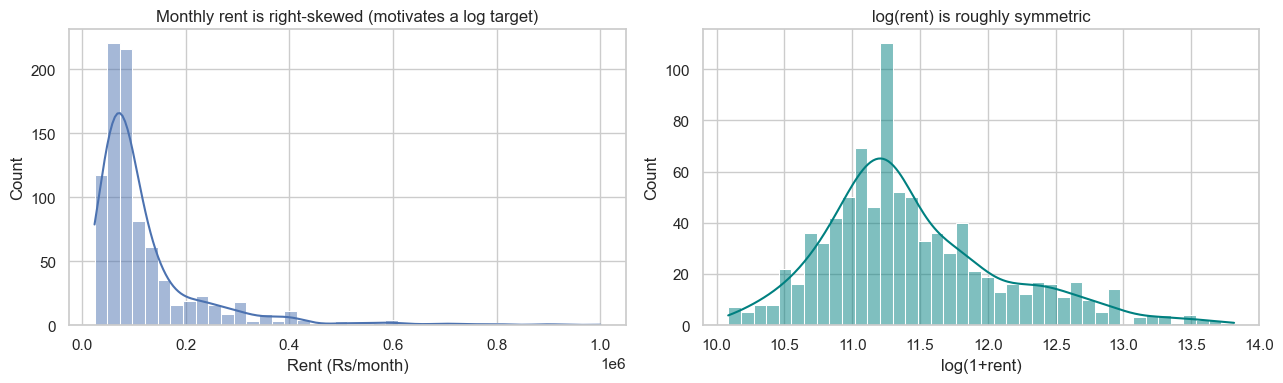

In [8]:
# Load the pipeline's clean outputs (identical cleaning + locality features).
listings = pd.read_csv(ROOT / "data/clean/listings_clean.csv")
loc = pd.read_csv(ROOT / "data/clean/localities.csv")[
    ["locality", "tier", "median_rent_per_sqft"]]
d = listings.merge(loc, on="locality", how="left")
print(f"{len(d)} listings, {d['locality'].nunique()} localities")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(d["price"], bins=40, kde=True, ax=ax[0])
ax[0].set(title="Monthly rent is right-skewed (motivates a log target)",
          xlabel="Rent (Rs/month)")
sns.histplot(np.log1p(d["price"]), bins=40, kde=True, color="teal", ax=ax[1])
ax[1].set(title="log(rent) is roughly symmetric", xlabel="log(1+rent)")
plt.tight_layout(); plt.show()

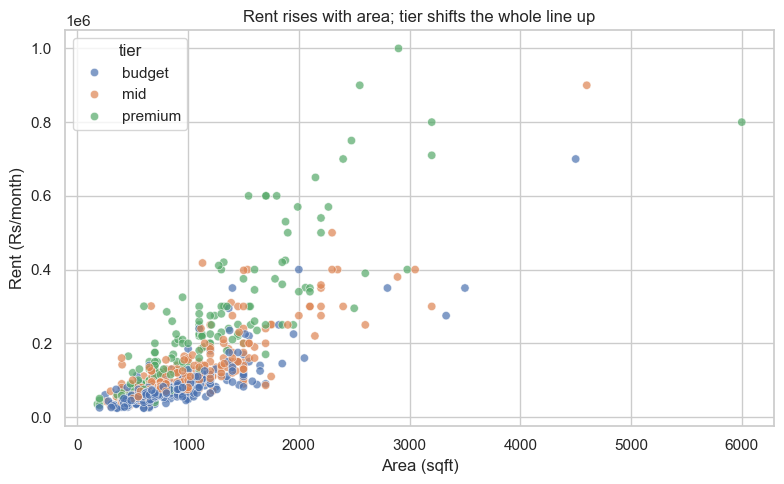

In [9]:
# Rent vs area, coloured by tier — the core relationship.
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=d, x="area_sqft", y="price", hue="tier", alpha=0.7, ax=ax)
ax.set(title="Rent rises with area; tier shifts the whole line up",
       xlabel="Area (sqft)", ylabel="Rent (Rs/month)")
plt.tight_layout(); plt.show()

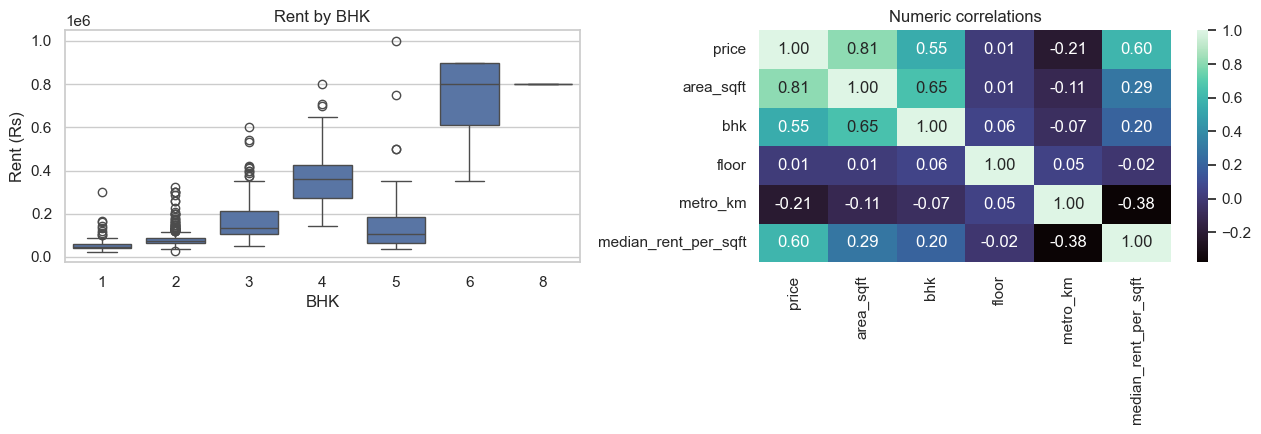

In [10]:
# Rent by BHK, and the numeric correlation heatmap.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=d, x="bhk", y="price", ax=ax[0])
ax[0].set(title="Rent by BHK", xlabel="BHK", ylabel="Rent (Rs)")
num = d[["price", "area_sqft", "bhk", "floor", "metro_km",
         "median_rent_per_sqft"]].dropna()
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="mako", ax=ax[1])
ax[1].set(title="Numeric correlations")
plt.tight_layout(); plt.show()

**What the EDA shaped:** rent is right-skewed and multiplicative, so we model
**log(rent)** and report errors back in rupees. Area and locality-median rent/sqft
correlate most strongly with price — they become the model's top features.

## Model — one linear regression on a proper evaluation

Exactly **one** model (linear regression). Evaluated by 5-fold cross-validation
because a single train/test split on this data swings with the random seed.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Leave-one-out locality rent/sqft: each flat sees the median of the OTHER flats
# in its locality, never its own price. Single-listing localities -> NaN -> filled
# with the city median below. Honest fix for the leak the plain locality median
# carries (for a lone listing that median IS its own rent/sqft).
def loo_median(s):
    v = s.to_numpy(dtype=float)
    return pd.Series([np.median(np.delete(v, i)) if len(v) > 1 else np.nan
                      for i in range(len(v))], index=s.index)
d["median_rps_loo"] = d.groupby("locality")["rent_per_sqft"].transform(loo_median)

# Area enters as log(area): a log-log (constant-elasticity) term. A raw area term
# under a log(rent) target predicts exp(b*area), which explodes for a rare huge flat
# (the lone 8BHK the raw-area model once priced at ~Rs 1.27 crore). log(area) removes
# that blow-up outright -- RMSE Rs 406k -> Rs 57k -- with no new model.
m = d.dropna(subset=["price", "area_sqft"]).copy()
m["log_area"] = np.log1p(m["area_sqft"])
feats_num = ["log_area", "bhk", "floor", "metro_km", "median_rps_loo"]
feats_cat = ["furnishing", "tier"]
m[feats_num] = m[feats_num].fillna(m[feats_num].median())
m[feats_cat] = m[feats_cat].fillna("unknown")

X = m[feats_num + feats_cat]
y = np.log1p(m["price"])                       # log target

pre = ColumnTransformer([
    ("num", StandardScaler(), feats_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feats_cat),
])
model = Pipeline([("pre", pre), ("lr", LinearRegression())])
print(f"Model rows: {len(X)}; features: {feats_num + feats_cat}")

Model rows: 882; features: ['log_area', 'bhk', 'floor', 'metro_km', 'median_rps_loo', 'furnishing', 'tier']


In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_folds = cross_val_score(model, X, y, cv=kf, scoring="r2")
oof = np.expm1(cross_val_predict(model, X, y, cv=kf))   # out-of-fold, rupees
true = np.expm1(y)
model.fit(X, y)
r2_in = r2_score(y, model.predict(X))

print(f"CV R2      : {r2_folds.mean():.3f} +/- {r2_folds.std():.3f}  "
      f"(folds {', '.join(f'{v:.2f}' for v in r2_folds)})")
print(f"OOF R2     : {r2_score(y, np.log1p(oof)):.3f}")
print(f"In-sample  : {r2_in:.3f}  -> overfitting gap {r2_in - r2_score(y, np.log1p(oof)):.3f}")
print(f"MAE        : Rs {mean_absolute_error(true, oof):,.0f}/month")
print(f"RMSE       : Rs {np.sqrt(mean_squared_error(true, oof)):,.0f}/month")

CV R2      : 0.807 +/- 0.042  (folds 0.81, 0.82, 0.82, 0.73, 0.86)
OOF R2     : 0.812
In-sample  : 0.818  -> overfitting gap 0.006
MAE        : Rs 28,676/month
RMSE       : Rs 56,874/month


### Which features carry the price, and by how much?

Numeric features are standardized, so each coefficient is the effect of a **+1
standard-deviation** move. The target is log(rent), so `exp(coef)-1` is the **%
change in rent**.

In [13]:
names = model.named_steps["pre"].get_feature_names_out()
coefs = model.named_steps["lr"].coef_
ct = pd.DataFrame({"feature": names, "coef_log": coefs})
ct["effect_on_rent"] = ct["coef_log"].map(lambda b: f"{np.expm1(b)*100:+.0f}%")
ct["abs"] = ct["coef_log"].abs()
ct.sort_values("abs", ascending=False)[["feature", "coef_log", "effect_on_rent"]].head(8)

,feature,coef_log,effect_on_rent
0,num__log_area,0.441734,+56%
11,cat__tier_premium,0.273118,+31%
9,cat__tier_budget,-0.231653,-21%
4,num__median_rps_loo,0.093808,+10%
1,num__bhk,0.055804,+6%
10,cat__tier_mid,-0.041465,-4%
5,cat__furnishing_furnished,0.041292,+4%
6,cat__furnishing_semi-furnished,-0.037048,-4%


**In plain words:** **area** — now entered as **log-area**, so its coefficient reads
as an elasticity (a *percent* change in size → a percent change in rent) — is the
single biggest genuine lever, then
**locality tier** (premium vs budget). With the locality rent/sqft now computed
leave-one-out, most of the neighbourhood signal loads onto the collinear `tier`
dummies rather than `median_rps_loo`. BHK adds on top; metro distance moves rent
only at the margin. The negative on `furnishing_unknown` is a *missingness*
signal — listings that hide furnishing tend to be cheaper.

## Where the model breaks (the honest part)

In [14]:
err = pd.DataFrame({
    "locality": m["locality"].values, "bhk": m["bhk"].values,
    "actual": true.values.round().astype(int),
    "predicted": oof.round().astype(int),
})
err["abs_err"] = (err["actual"] - err["predicted"]).abs()
err.sort_values("abs_err", ascending=False).head(5)

,locality,bhk,actual,predicted,abs_err
67,Gundavali,6,900000,434618,465382
412,Santacruz West,8,800000,1247582,447582
778,Worli,5,1000000,622584,377416
552,Andheri West,6,900000,557410,342590
28,Pali Hill,4,600000,266189,333811


**Failure pattern:** with area on a log scale the luxury tail no longer explodes —
the lone 8BHK the raw-area model priced at ~₹1.27 crore now lands near ₹12.5 lakh, and
the worst miss across all 882 rows is a ~₹4.7-lakh over/under-shoot on a rare 6BHK, not
an order-of-magnitude error. RMSE now sits close to MAE. Residual misses are rare large
flats and thin single-listing localities; it is reliable for typical 1–3 BHK rent.

## Limitations & what would fix it

- Single source (Square Yards), one city (Mumbai) — by design, but selection bias.
- Many localities still have a single listing → their features rest on one flat.
- Locality strength enters via `median_rps_loo`, a **leave-one-out** median (each
  flat sees only the *other* flats in its locality), closing the solo-locality leak
  the raw locality median carried; most of that signal loads onto collinear `tier`.
- **The highest-return fix is more listings per locality**, then a second source,
  then real amenity fields (building age, lift, parking). The ceiling here is the
  **data, not the algorithm** — spend the next effort on rows, not a second model.